# **Data Mining Social Media: FIFA Uniform Color-Sentiment App**

Data Mining Social Media using Mastodon, JSON, Sentiment Analysis

My app is **FIFA Uniform Design** with a focus on **Color Sentiment**.

This notebook contains **four programs**:

1. **Authentication**
2. **Creating an APP a): Collect posts about FIFA uniforms**
3. **Creating an APP b): Sentiment analysis (TextBlob + NaiveBayesAnalyzer)**
4. **Creating an APP c): Color-keyword extraction + per-color sentiment + word cloud**

In [1]:
# Set up 1 — Install the libraries this app needs
# Mastodon.py = social-media API client (the Tweepy equivalent for Mastodon)
# textblob / nltk / wordcloud
!pip install Mastodon.py textblob wordcloud -q

In [2]:
# Imports and one-time NLTK/TextBlob data downloads
from mastodon import Mastodon
from textblob import TextBlob
from textblob.sentiments import NaiveBayesAnalyzer
from wordcloud import WordCloud
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
import nltk, re, json
from collections import defaultdict, Counter

# Corpora used by TextBlob's NaiveBayesAnalyzer and by tokenization
nltk.download('movie_reviews')
nltk.download('punkt')
nltk.download('punkt_tab')
print("Libraries loaded.")

Libraries loaded.


[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Package movie_reviews is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [3]:
MASTODON_API_BASE_URL = "" # Initialize with a default empty string
MASTODON_ACCESS_TOKEN = "" # Initialize with a default empty string

#Load Mastodon credentials
try:
    import keys
    MASTODON_API_BASE_URL = getattr(keys, "mastodon_api_base_url", MASTODON_API_BASE_URL)
    MASTODON_ACCESS_TOKEN = getattr(keys, "mastodon_access_token", MASTODON_ACCESS_TOKEN)
    print("Loaded Mastodon credentials from keys.py")
except Exception:
    print("No keys.py found.")

print("Instance :", MASTODON_API_BASE_URL)
print("Token set:", "yes" if MASTODON_ACCESS_TOKEN.strip() else "no (will use sample data)")

No keys.py found.
Instance : 
Token set: no (will use sample data)


## 1 — Authentication

**Goal:** confirm my credentials work by connecting to the API and requesting my own account information. If the service returns a valid object, authentication succeeds. The response comes back as **JSON**.

In [4]:
#1 — Authenticate and request my own account info
mastodon = None
auth_ok = False

if MASTODON_ACCESS_TOKEN.strip():
    try:
        mastodon = Mastodon(access_token=MASTODON_ACCESS_TOKEN,
                            api_base_url=MASTODON_API_BASE_URL)
        me = mastodon.me()          # returns a JSON object
        auth_ok = True
        print("Authentication SUCCEEDED. Account info (selected JSON fields):")
        print("  username     :", me['username'])
        print("  display name :", me['display_name'])
        print("  account id   :", me['id'])
        print("  followers    :", me['followers_count'])
        print("  statuses     :", me['statuses_count'])
    except Exception as e:
        print("Authentication FAILED:", e)

else:
    print("No access token set — skipping live auth and using sample data below.")

No access token set — skipping live auth and using sample data below.


## 2 — APP Creation a): Collect posts about FIFA uniforms

**Goal:** use the API's search/timeline endpoints to gather recent public posts about **FIFA / World Cup uniforms (kits, jerseys, shirts)**. Each post arrives as a **JSON object**; I strip the HTML from the post body using BS, keep the plain text, and store the cleaned posts in a list — the raw material for sentiment
analysis. If the live API isn't available, a built-in `SAMPLE_POSTS` list is used so the pipeline still
runs.

In [5]:
# Built-in sample used ONLY if the live API is unavailable.
SAMPLE_POSTS = [
    "The new Brazil kit for the World Cup is stunning — that bright yellow and green looks incredible.",
    "Not a fan of the grey away jersey, it looks so dull and washed out on the pitch.",
    "Argentina's blue and white stripes are timeless. Best uniform at the FIFA tournament by far.",
    "Why is the Germany kit black this year? It looks aggressive but honestly a bit boring.",
    "That neon orange Netherlands shirt is bold and beautiful, love the energy it brings.",
    "The red Spain jersey is gorgeous, such a rich crimson color. Instant classic.",
    "France in navy blue looks elegant and clean, a really classy uniform design.",
    "The gold trim on the Portugal kit is a nice touch, feels premium and proud.",
    "England's plain white shirt is so bland, they never take risks with the color.",
    "Loving the purple accents on the new goalkeeper jersey, very unique and fresh.",
    "The pink third kit is surprisingly great, playful and modern. Big fan.",
    "Ugly. The green and orange clash on that away kit hurts my eyes.",
    "Italy's azure blue is beautiful as always, one of the most iconic uniform colors in football.",
    "The all-black referee uniform looks sleek and professional this World Cup.",
    "Croatia's red and white checkerboard is iconic — bold, sharp and unforgettable.",
    "Disappointed by the dull maroon kit, it looks muddy under the stadium lights.",
    "The sky blue Uruguay shirt is so clean and calming, really nice design work.",
    "Mexico's green jersey with gold detailing looks vibrant and festive. Love it.",
    "That silver away kit is boring and forgettable, zero personality.",
    "The bright red Belgium kit pops on screen, fantastic color choice for the tournament.",
    "Japan's deep blue uniform is elegant and the subtle pattern is a beautiful detail.",
    "Terrible teal keeper kit, the color just does not work with the rest of the uniform.",
    "The yellow and blue Sweden shirt is cheerful and bold, great World Cup look.",
    "Morocco in red with green trim looks powerful and proud, a striking uniform.",
    "The white and gold kit looks luxurious and premium. Best design of the whole FIFA lineup.",
    "Honestly the orange goalkeeper jersey is hideous this year, awful color combo.",
    "Portugal's deep red home shirt is bold and passionate, love the intensity of the color.",
    "The pale grey change strip is lifeless, wish they had picked a brighter color.",
    "Ghana's red, gold and green kit is vibrant and full of pride. Gorgeous uniform.",
    "The navy and crimson combination on that new jersey is sharp and modern, really well done.",
]

def clean_html(html_text):
    """Strip HTML tags from a Mastodon post body and return plain text."""
    return BeautifulSoup(html_text, "html.parser").get_text(separator=" ").strip()

def collect_live_posts(client, hashtags, target=40):
    """Pull recent public posts for several hashtags and keep the ones about uniforms/colors."""
    keep = ["kit", "jersey", "shirt", "uniform", "strip", "color", "colour"]
    seen, posts = set(), []
    for tag in hashtags:
        try:
            timeline = client.timeline_hashtag(tag, limit=40)
        except Exception as e:
            print(f"  (hashtag #{tag} failed: {e})")
            continue
        for status in timeline:
            text = clean_html(status.get("content", ""))
            low = text.lower()
            if len(text) < 20 or text in seen:
                continue
            if any(k in low for k in keep) or tag in ("worldcupkits", "footballshirts"):
                seen.add(text)
                posts.append(text)
        if len(posts) >= target:
            break
    return posts

posts = []
if auth_ok and mastodon is not None:
    posts = collect_live_posts(
        mastodon,
        hashtags=["WorldCup", "FIFA", "footballshirts", "worldcupkits", "jersey", "football"],
        target=40,
    )
    print(f"Collected {len(posts)} live posts about FIFA uniforms.")

if not posts:
    posts = SAMPLE_POSTS
    print(f"Using {len(posts)} built-in sample posts (live data unavailable).")

# Save the collected data to a JSON file
with open("fifa_uniform_posts.json", "w") as f:
    json.dump(posts, f, indent=2)

print("\nFirst 3 posts:")
for p in posts[:3]:
    print(" -", p)

Using 30 built-in sample posts (live data unavailable).

First 3 posts:
 - The new Brazil kit for the World Cup is stunning — that bright yellow and green looks incredible.
 - Not a fan of the grey away jersey, it looks so dull and washed out on the pitch.
 - Argentina's blue and white stripes are timeless. Best uniform at the FIFA tournament by far.


## 3 — APP Creation b): Sentiment Analysis

**Goal**: **measure the sentiment of the collected posts.**

- **TextBlob** gives each post a **polarity** (-1 negative → +1 positive) and **subjectivity** (0–1).
- I compute the **overall average polarity** and classify each post as positive / neutral / negative.
- I also run TextBlob's **`NaiveBayesAnalyzer`** (trained on the movie-review corpus) on a few posts to
  show a second machine-learning-based sentiment method.

In [6]:
#TextBlob polarity/subjectivity for every post
def polarity(text):
    return TextBlob(text).sentiment.polarity

def classify(p):
    if p > 0.05:  return "positive"
    if p < -0.05: return "negative"
    return "neutral"

scored = []
for text in posts:
    b = TextBlob(text)
    scored.append({
        "text": text,
        "polarity": round(b.sentiment.polarity, 3),
        "subjectivity": round(b.sentiment.subjectivity, 3),
        "label": classify(b.sentiment.polarity),
    })

avg = sum(s["polarity"] for s in scored) / len(scored)
counts = Counter(s["label"] for s in scored)

print(f"Analyzed {len(scored)} posts")
print(f"Overall average polarity: {avg:+.3f}  ({classify(avg)})")
print("Breakdown:", dict(counts))
print("\nMost positive post:", max(scored, key=lambda s: s["polarity"])["text"])
print("Most negative post:", min(scored, key=lambda s: s["polarity"])["text"])

Analyzed 30 posts
Overall average polarity: +0.089  (positive)
Breakdown: {'positive': 21, 'negative': 9}

Most positive post: The gold trim on the Portugal kit is a nice touch, feels premium and proud.
Most negative post: Terrible teal keeper kit, the color just does not work with the rest of the uniform.


In [7]:
#NaiveBayesAnalyzer
# It is slow, so we run it on the first 5 posts to demonstrate the technique.
print("NaiveBayesAnalyzer sentiment (first 5 posts):\n")
for text in posts[:5]:
    nb_blob = TextBlob(text, analyzer=NaiveBayesAnalyzer())
    s = nb_blob.sentiment
    print(f"[{s.classification}]  p_pos={s.p_pos:.2f}  p_neg={s.p_neg:.2f}")
    print("   ", text, "\n")

NaiveBayesAnalyzer sentiment (first 5 posts):



[pos]  p_pos=0.75  p_neg=0.25
    The new Brazil kit for the World Cup is stunning — that bright yellow and green looks incredible. 



[neg]  p_pos=0.06  p_neg=0.94
    Not a fan of the grey away jersey, it looks so dull and washed out on the pitch. 



[pos]  p_pos=0.56  p_neg=0.44
    Argentina's blue and white stripes are timeless. Best uniform at the FIFA tournament by far. 



[neg]  p_pos=0.27  p_neg=0.73
    Why is the Germany kit black this year? It looks aggressive but honestly a bit boring. 



[pos]  p_pos=0.96  p_neg=0.04
    That neon orange Netherlands shirt is bold and beautiful, love the energy it brings. 



## 4 — APP Creation c): Color-Keyword Extraction + Color Sentiment + Word Cloud

**Goal — the core of my FIFA app:** find which **colors** people mention when talking about uniforms,
and what **sentiment** is attached to each color.

For every post I detect color words, then attribute that post's TextBlob polarity to each color it mentions. Aggregating across all posts gives an **average sentiment per color** and a **mention count**, which I visualize with a bar chart. Finally I build a **word cloud** of the posts to show
the most prominent uniform-design vocabulary.

In [8]:
#4a — Extract color keywords and attach sentiment to each color
COLORS = ["red", "blue", "navy", "sky blue", "green", "yellow", "gold", "white",
          "black", "orange", "purple", "pink", "maroon", "crimson", "teal",
          "silver", "grey", "gray", "azure"]

color_polarities = defaultdict(list)
for s in scored:
    low = s["text"].lower()
    for color in COLORS:
        if re.search(r"\b" + re.escape(color) + r"\b", low):
            color_polarities[color].append(s["polarity"])

# Build a summary: average sentiment + number of mentions per color
summary = []
for color, pols in color_polarities.items():
    summary.append((color, sum(pols) / len(pols), len(pols)))
summary.sort(key=lambda x: x[2], reverse=True)   # most-mentioned first

print(f"{'COLOR':<10}{'MENTIONS':>9}{'AVG SENTIMENT':>16}")
print("-" * 35)
for color, avg_p, n in summary:
    print(f"{color:<10}{n:>9}{avg_p:>+16.3f}")

COLOR      MENTIONS   AVG SENTIMENT
-----------------------------------
blue              6          +0.302
red               6          +0.244
green             5          +0.106
white             4          +0.200
gold              4          +0.365
orange            3          -0.030
yellow            2          +0.323
grey              2          -0.151
black             2          -0.044
crimson           2          +0.155
navy              2          +0.172
purple            1          +0.381
pink              1          +0.180
azure             1          +0.463
maroon            1          -0.521
sky blue          1          +0.322
silver            1          -0.750
teal              1          -1.000


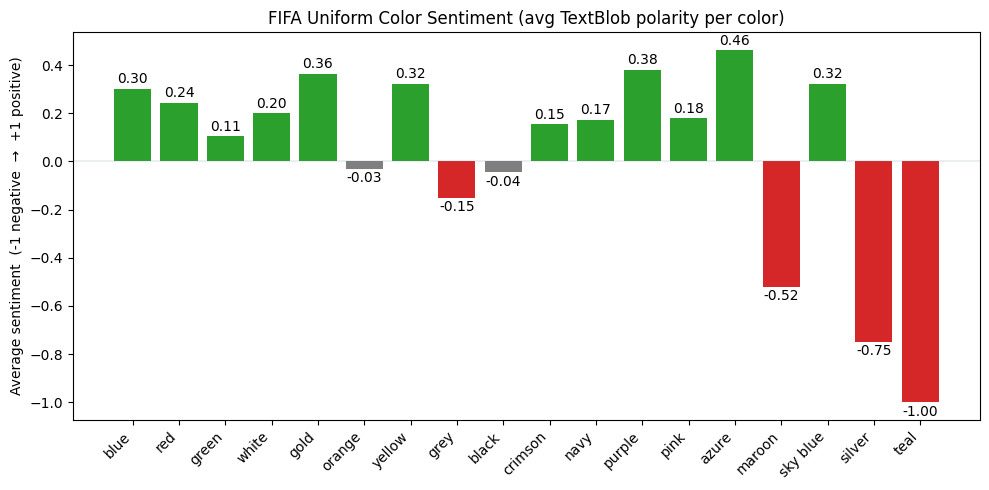

In [9]:
#4b — Visualize average sentiment per color in a bar chart
if summary:
    labels = [c for c, _, _ in summary]
    values = [a for _, a, _ in summary]
    bar_colors = ["#2ca02c" if v > 0.05 else "#d62728" if v < -0.05 else "#7f7f7f"
                  for v in values]

    plt.figure(figsize=(10, 5))
    bars = plt.bar(labels, values, color=bar_colors)
    plt.axhline(0, color="#778899", linewidth=0.2)

    # Add text labels on each bar
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01 * (1 if yval >= 0 else -1),
                 f'{yval:.2f}', ha='center', va='bottom' if yval >= 0 else 'top')

    plt.title("FIFA Uniform Color Sentiment (avg TextBlob polarity per color)")
    plt.ylabel("Average sentiment  (-1 negative  →  +1 positive)")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("No color keywords were found in the collected posts.")

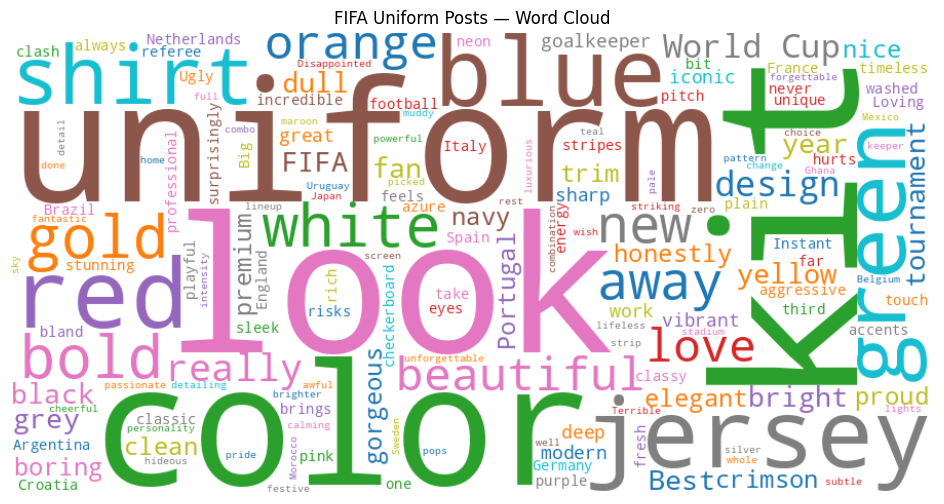

In [10]:
#4c — Word cloud of the collected posts
all_text = " ".join(posts)
wc = WordCloud(width=900, height=450, background_color="white",
               colormap="tab10").generate(all_text)
plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("FIFA Uniform Posts — Word Cloud")
plt.show()

## **Conclusion**

The application collects public posts about **FIFA uniforms**, scores their sentiment with **TextBlob** and
**`NaiveBayesAnalyzer`**, and then extracts **color keywords** to reveal which uniform colors draw positive
versus negative reactions.

The figures below come from the built-in `SAMPLE_POSTS` fallback (30 posts), which is what the notebook
analyzes when no Mastodon access token is supplied. Overall sentiment toward FIFA uniforms is mildly
positive (average polarity **+0.089**; 21 positive posts, 9 negative).

Per color, the warm and saturated tones score best — **gold** (+0.365, 4 mentions), **yellow** (+0.323, 2),
**blue** (+0.302, 6) and **red** (+0.244, 6) all draw clearly positive reactions, and **white** (+0.200, 4)
is mildly positive. The negative end is dominated by muted or desaturated colors: **teal** (-1.000, 1),
**silver** (-0.750, 1), **maroon** (-0.521, 1) and **grey** (-0.151, 2), with **orange** (-0.030, 3) and
**black** (-0.044, 2) essentially neutral.

The pattern suggests that, within this sample, **saturation matters more than hue**: vivid colors are
described with words like *stunning*, *vibrant* and *bold*, while washed-out colors attract *dull*,
*lifeless* and *forgettable*. Two caveats are worth stating. First, several colors rest on a single post,
so their averages are anecdotal rather than reliable — the one-mention extremes (teal, silver, azure)
should not be read as findings. Second, the color matcher counts compound names twice: "navy blue" is
credited to both *navy* and *blue*, and "sky blue" to both *sky blue* and *blue*.

Taken together, the results demonstrate how social-media text can be mined to extract color-specific
sentiment patterns, while illustrating why a sample this small supports illustration rather than
inference.